# Anforderungen an Projektumsetzung: Clustering

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



#### Führen Sie mit dem Algorithmus Ihrer Wahl eine Clusteranalyse auf Ihren Daten durch.

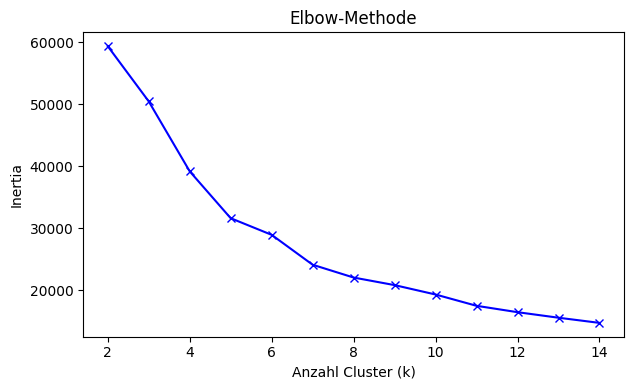

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Daten mit spezifischen Spalten laden
columns_to_use = ['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']
df = pd.read_csv("survey_results_shortened.csv", usecols=columns_to_use)

# 2. Fehlende Werte behandeln
df_clean = df.dropna()  # Oder geeignete Imputation

# 3. Daten skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# 4. Beste Clusteranzahl finden
K = range(2, 15)
inertias = []


for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)


# 5. Elbow- und Silhouetten-Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bx-')
plt.title('Elbow-Methode')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()

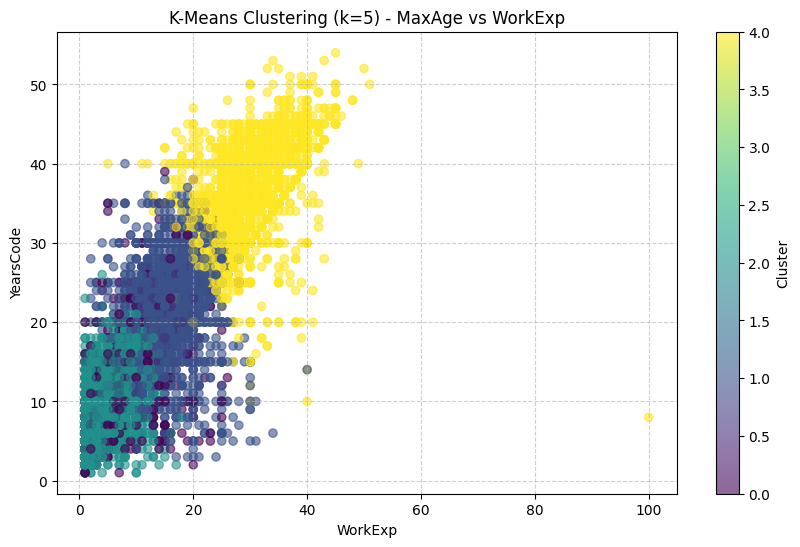


Cluster-Statistiken:
         MaxAge  YearsCode  WorkExp  JobSat  ConvertedCompYearly
Cluster                                                         
0         37.79      13.53     9.29    3.63             85725.73
1         44.62      20.84    15.83    7.84            128594.49
2         32.63      10.21     6.04    7.72             71111.52
3         44.00      27.00    20.00    7.00          33552715.00
4         56.89      34.78    28.72    7.45            128688.32


/var/folders/dr/lf4__k395mg4yymndm95cms00000gn/T/ipykernel_27419/3607041010.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = clusters


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

best_k = 5

# 7. Finales Modell
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = final_kmeans.fit_predict(X_scaled)

# 8. Visualisierung mit MaxAge und WorkExp
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['WorkExp'],
                     df_clean['YearsCode'],
                     c=clusters,
                     cmap='viridis',
                     alpha=0.6)
plt.xlabel('WorkExp')
plt.ylabel('YearsCode')
plt.title(f'K-Means Clustering (k={best_k}) - MaxAge vs WorkExp')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 9. Cluster-Statistiken
df_clean['Cluster'] = clusters
print("\nCluster-Statistiken:")
print(df_clean.groupby('Cluster')[columns_to_use].mean().round(2))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dennyredel/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/dennyredel/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/dennyredel/nltk_data...


Found 106 non-numeric columns


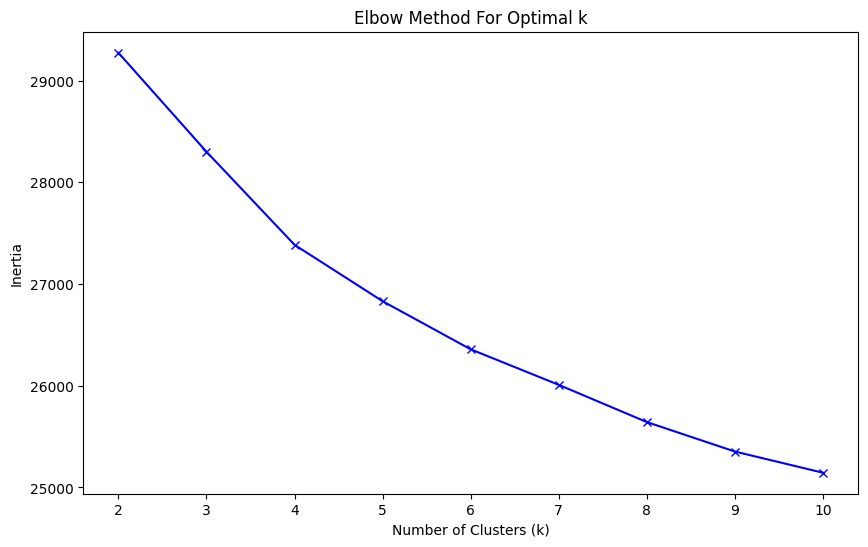


Top terms per cluster:

Cluster 0:
 developer
 year
 old
 profession
 new
 coding
 employed
 degree
 bachelor
 none

Cluster 1:
 model
 ai
 agent
 code
 yes
 openai
 reasoning
 github
 tool
 gemini

Cluster 2:
 ai
 agent
 code
 yes
 tool
 use
 new
 stack
 github
 learning

Cluster 3:
 online
 ai
 tool
 yes
 coding
 new
 enabled
 stack
 certification
 course

Cluster 4:
 ai
 code
 agent
 yes
 stack
 tool
 github
 shell
 use
 new

Cluster sizes:
cluster
0     6111
1     8090
2     8733
3    10123
4    14666
Name: count, dtype: int64

Clustering completed. Results saved to 'clustered_survey_results.csv'


In [5]:
# Text Clustering for Non-Numeric Columns

## 1. Load and Prepare Data
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the data
df = pd.read_csv("survey_results_shortened.csv")

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(f"Found {len(non_numeric_cols)} non-numeric columns")

## 2. Text Preprocessing
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

# Combine all non-numeric text into a single column
df['combined_text'] = df[non_numeric_cols].fillna('').astype(str).apply(' '.join, axis=1)
df['processed_text'] = df['combined_text'].apply(preprocess_text)

## 3. TF-IDF Vectorization
# Limit to 1000 max features to keep computation manageable
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['processed_text'])

## 4. Elbow Method to Find Optimal Number of Clusters
# Calculate inertia for different numbers of clusters
inertias = []
K = range(2, 11)  # Testing 2-10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

## 5. Perform KMeans Clustering with Selected k
# Let's choose k based on the elbow point (you may need to adjust this)
optimal_k = 5  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Add cluster labels to the dataframe
df['cluster'] = cluster_labels

## 6. Analyze Clusters
# Get top terms per cluster
print("\nTop terms per cluster:")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(optimal_k):
    print(f"\nCluster {i}:")
    for ind in order_centroids[i, :10]:  # Top 10 terms per cluster
        print(f' {terms[ind]}')

# Show cluster sizes
print("\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

## 7. Save Results
df[['cluster'] + non_numeric_cols[:5]].to_csv('clustered_survey_results.csv', index=False)
print("\nClustering completed. Results saved to 'clustered_survey_results.csv'")